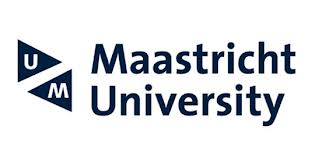


# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours

By Jan Scholtes - Version 2026-2027


Welcome to the tutorial on Tokenization. In this notebook you will learn how to preprocess text into tokens — the fundamental building blocks of any NLP pipeline. Tokenization is closely related to sentence detection, stemming, lemmatization and is part of the larger NLP research area known as morphology.

Tokenization is highly language dependent. In this tutorial we focus primarily on Western-European languages, but we also touch upon challenges that arise with other scripts and multilingual text.

Tokenization is where any NLP application starts. Errors in tokenization propagate throughout all subsequent processes. Non-recognized tokens, mis-recognized tokens, and incorrectly removed tokens are just a few of the problems that lead to lower performance further down in your pipeline. That is why it is essential to understand how well your tokenizer does its job — and when it fails.

### What this notebook covers

We begin in **Phase 1** by examining why tokenization matters in the real world: how poor tokenization causes information retrieval failures (e.g., searching for "New York City") and how morphological confusion affects matching (e.g., "running" vs. "runs" vs. "runner").

**Phase 2** introduces the statistical foundation: **Zipf's Law** and the long tail distribution of words. We discuss why most words in a corpus are rare, how this motivates preprocessing steps like stop word removal and morphological normalization, and when modern neural models make different trade-offs than classical IR systems.

From there, we move into hands-on practice with the core components of a text preprocessing pipeline:

- **Text extraction and cleanup** — scraping and parsing text from HTML using BeautifulSoup
- **Sentence detection** — splitting text into sentences with NLTK
- **Tokenization** — comparing simple splitting, NLTK's `word_tokenize`, and regex-based tokenizers (`RegexpTokenizer`), including building improved regex patterns for edge cases like abbreviations, emails, and numbers
- **Vocabulary generation** — building a unique word list from a tokenized corpus
- **Stop word removal** — filtering out high-frequency, low-information words and understanding when this helps vs. hurts
- **Stemming** — rule-based suffix stripping with the Porter stemmer
- **Lemmatization** — dictionary-based reduction to base forms with WordNet
- **Text normalization** — handling social media shorthand, hashtags, emoticons, and inconsistent formatting
- **Language detection** — identifying the language of a text, which is essential since almost all NLP models are language-specific
- **Transliteration** — mapping between writing systems based on phonetic similarity (e.g., Cyrillic to Latin)

We then move to **subword tokenization** — a modern approach used by transformer models like BERT and GPT. We compare **WordPiece** tokenization against traditional word-level methods, showing how subword approaches handle unknown and rare words by splitting them into meaningful pieces rather than treating them as opaque tokens.

The notebook concludes with **advanced topics** that go beyond standard text tokenization:

- **Domain-specific tokenization** — designing pipelines for specialized text such as medical notes, where terms like "ICD-10: E11.9" and "120/80 mmHg" must be preserved as meaningful units
- **Tokenization for non-textual sequences** — how to tokenize DNA sequences (using k-mer tokenization or BPE) and chemical formulas/SMILES notation, where standard word-level approaches are entirely inapplicable
- **Detecting and fixing OOV (out-of-vocabulary) problems** — how to diagnose when a pre-trained tokenizer fragments domain terms into meaningless subword pieces, how to detect misused subwords that carry the wrong semantics, and strategies for building better-matching vocabularies through training domain-specific tokenizers, extending existing vocabularies, and domain-adaptive pretraining

Throughout the notebook, exercises (A1–A5) give you hands-on practice with these concepts, from basic tokenization comparison through stop word analysis, morphological processing decisions, WordPiece vs. word-level comparison, and designing a complete domain-specific tokenization pipeline.

# Phase 1: The Tokenization Problem in the Real World

Before we dive into technical solutions, let's understand why tokenization is a critical problem in NLP.

## Problem 1: NLP Failure

Imagine you're processing information about "New York City".

**Without proper tokenization:**
- System splits on spaces: "New", "York", "City"
- Returns results mentioning "New" separately from "York" and "City"
- You get irrelevant results about "new products" and "city maps"

**With proper tokenization:**
- System recognizes "New York City" as a named entity
- Returns highly relevant articles about New York City
- Search precision increases significantly

**Real-world impact:** E-commerce searches, news aggregation, legal document retrieval

## Problem 2: Morphological Confusion

Consider these words: "running", "runs", "runner"

**Without morphological processing:**
- These are treated as 3 completely separate, unrelated concepts
- Statistical analysis treats them as independent events
- If "running" appears 5 times and "runs" appears 3 times, system sees 8 separate instances

**With lemmatization/stemming:**
- All three map to the common root: "run"
- Combined frequency: 8 instances of the concept "run"
- Statistical significance improves, algorithms work better

**Real-world impact:** Text classification, sentiment analysis, topic modeling

## Problem 3: Out-of-Vocabulary Catastrophe

Consider a rare word: "unfathomable"

**Traditional word-level tokenizers:**
- If the word isn't in their training vocabulary, it becomes `[UNK]` (unknown token)
- System has NO idea what this word means
- Complete loss of information

**Modern subword tokenizers (WordPiece):**
- Even if "unfathomable" isn't in vocabulary, it can be broken down
- Becomes: ["un", "fath", "##om", "##able"]
- System can understand morphological structure and partial meaning
- Graceful degradation instead of complete failure

**Real-world impact:** Handling rare words, slang, misspellings, technical terminology, multilingual text

## Problem 4: Domain-Specific Ambiguity

The same text needs different tokenization for different domains:

**E-commerce Example:**
- Product: "iPhone 13 Pro Max"
- Bad tokenization: Treats "Pro" and "Max" separately
- Good tokenization: Recognizes "Pro Max" as a product tier
- Impact: Users searching for "Pro Max phones" find what they want

**Medical Example:**
- Diagnosis: "Type 2 Diabetes Mellitus"
- Bad tokenization: ["Type", "2", "Diabetes", "Mellitus"]
- Good tokenization: ["Type 2 Diabetes Mellitus"] (one medical concept)
- Impact: Drug recommendations, diagnostic coding accuracy

**Legal Example:**
- Contract term: "Act of God"
- Bad tokenization: Three separate words with no connection
- Good tokenization: Single legal/insurance concept
- Impact: Contract analysis, risk assessment, liability determination

## Interactive Challenge: Predict Tokenization Outputs

Before we show you how to tokenize text, try to predict the outcomes!

**Text samples to tokenize:**
1. "don't" - Does the apostrophe split it?
2. "john.doe@example.com" - How does email get split?
3. "Dr. Smith" - What happens to abbreviations?
4. "award-winning" - Does the hyphen cause a split?
5. "U.S.A." - Multiple dots and capitals?

**For each, ask yourself:**
- Should it be 1 token or multiple?
- What would a search engine need?
- What would a language model need?

We'll test your predictions with real tokenizers in the next sections!

# Phase 2: Understanding the Long Tail - Why Preprocessing Matters

Natural language exhibits a remarkable property: **most words are rare**.

A few words (the, a, is, and, ...) appear extremely frequently, while most words appear only occasionally. This is called **Zipf's Law** or the "long tail distribution".

## Why This Matters for IR and NLP

**For Information Retrieval (Historical Perspective):**
- In the 1970s-1990s, computer memory was expensive and limited
- Idea: Remove the most frequent words ("stop words") to save space and improve relevance
- Result: Faster search, smaller indexes, but loss of search capability for phrases like "to be or not to be"

**For Modern NLP:**
- GPU memory is still valuable, but rarely the limiting factor
- Frequency information is actually useful for context and meaning
- Neural models (transformers) learn that context words help determine meaning
- Modern best practice: **Keep stop words** with neural models

**The Long Tail Property Means:**
- Most words are rare → algorithms need sufficient data to learn statistics
- Morphological processing helps group related rare words
- Rare words are often the most informative (e.g., "diabetes" > "the")
- Better preprocessing → Better statistical significance → Better algorithm performance

Text extraction and cleanup is an important component of real-world NLP systems. Text extraction allows one to extract text from various electronic file formats (TXT, HTML, XML, PDF, DOCX, XLSX, PPTX, ...) and deals with the encoding of the characters (Unicode, UTF-8, Code pages or ACSII).

PDF can be quite challenging, especially from a formatting point of view. There are also many PDF reverse engineered formats that do not follow the official PDF guideliness completely. For popular formats from Microsoft, Google, Open Office and other vendors, there are several open source libraries to exract text and meta data. For more obscure file types, one has to fall back to commercial solutions such as Oracle Outside In, but these can be expensive.

Encoding normalization is important to map various variants of code pages (https://en.wikipedia.org/wiki/Code_page ), ASCII and other encodings to one common Unicode format (https://home.unicode.org/). UTF-8 is the most used one.

In this tutorial, we presume all this has been done and we can start with UTF-8 text files that only contain basic line (CR-LF) and tab formatting.

# NLTK

First we load NLTK

In [ ]:
import nltk
nltk.download('punkt') # load tokenization
nltk.download('punkt_tab')

NLTK also contains many text corpora. Let's import the movie reviews.

In [ ]:
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews
movie_reviews.readme()

Let's see what is in there

In [ ]:
raw = movie_reviews.raw()
print(raw[0:1000:1]) # print first 1000 chars


Let's see if we can detect the long tail that is typical for natural language. First we seperate the text in indivudual words, then we run a frequency analsyis on the results.

In [ ]:
corpus = movie_reviews.words()
print(corpus)
freq_dist = nltk.FreqDist(corpus)
print(freq_dist)
print(freq_dist.most_common(50))
freq_dist.plot(500)

## Observations from the Long Tail

What you're seeing is **Zipf's Law in action**:
- A few words (the, and, a, ...) dominate the corpus
- Most words appear very rarely (thousands of unique words appear only once)
- This creates a characteristic "long tail" distribution when plotted

**Historical Consequence for IR:**
For decades, systems removed these frequent words ("stop words") because they:
- Waste storage space
- Add noise to relevance calculations
- Don't help distinguish between documents

**Modern Consequence for NLP:**
Today we know:
- Frequency information carries meaning
- Context words help disambiguate rare words
- Stop word removal often HURTS neural network performance
- Better to keep them and let the model learn what's important

As you can also observe, punctuation characters such as .  and , and other ones (: ; " " ? ! ) are still in there. This is where tokenization comes in. Tokenization removes punctuations where they are used as sentence and phrase seperation, but leaves them where they are part of a token (e.g. an email address or abbreviation).  

# Sentence Detection

Next, we load the NLTK tokenizer for sentences (sent_tokenize) and for words (word_tokenize)

In [ ]:
from nltk.tokenize import sent_tokenize, word_tokenize

In [ ]:
my_text = "The Department of Advanced Computing Sciences - sometimes abbreviated as DACS - \n is Maastricht University's largest and oldest department \n broadly covering the fields of artificial intelligence, data science, computer science, \n mathematics and robotics. We maintain a large network of public and \n private partners through our research collaborations and through the \n award-winning KE@Work programme. In addition, our staff teaches approximately 800 bachelor's and master's \n students in 3 specialized study programmes in Data Science \n and Artificial Intelligence. The Department of Advanced Computing Sciences \n  is the new joint identity of the Institute of Data Science (IDS) and the former \n Department of Data Science and Knowledge Engineering (DKE)."
print(my_text)


In [ ]:
my_sentences = sent_tokenize(my_text)
# print(my_sentences) # print entire list unformatted
print("\n")
for x in range(len(my_sentences)):
    print(my_sentences[x]+"\n")

# Word Detection aka Tokenization

# Phase 3: Level 1 - Word-Level Tokenization

## Common Misconceptions About Tokenization

**Misconception 1: "All tokenizers work the same way"**
- FALSE - Different tokenizers make different design choices
- TRUTH - NLTK, spaCy, transformers, and regex tokenizers produce different results
- Implication: Choice of tokenizer affects downstream IR/NLP performance

**Misconception 2: "Punctuation should always be removed"**
- FALSE - Context matters!
- TRUTH - Some punctuation is meaningful (emails: user@domain.com, abbreviations: "Dr.", URLs)
- Implication: Blind punctuation removal can lose information

**Misconception 3: "Tokenization is one-size-fits-all"**
- FALSE - Different domains need different strategies
- TRUTH - Medical text, legal text, and code require domain-specific tokenizers
- Implication: Task and domain should guide tokenization strategy

## Tokenization Design Choices

When building a tokenizer, designers must answer:

1. **What is a token boundary?** (spaces, punctuation, morphemes?)
2. **What to do with punctuation?** (remove, keep attached, separate?)
3. **Case sensitivity?** (preserve or normalize?)
4. **Contractions and possessives?** ("don't" → ["do", "n't"] or ["don't"]?)
5. **Hyphenated words?** ("award-winning" → ["award", "-", "winning"] or ["award-winning"]?)
6. **Special symbols?** (emails, URLs, @mentions, #hashtags?)

Different answers lead to different tokenization outputs. Let's compare several strategies on the same text:

Given a character sequence and a defined document unit, tokenization is the task of chopping it up into pieces, called tokens , perhaps at the same time throwing away certain characters, such as punctuation.
A token is an instance of a sequence of characters in some particular document that are grouped together as a useful semantic unit for processing. A type is the class of all tokens containing the same character sequence.

In [ ]:
for sentence in my_sentences:
    print("Sentence: "+str(sentence))
    my_words = word_tokenize(sentence)
    print("Tokens: ")
    for x in range(len(my_words)):
      print("    "+str(my_words[x]))


As you can observe, there are still punctuation in the list of tokens. In NLTK these can be removed by using a regular expression.

In [ ]:
from nltk.tokenize import RegexpTokenizer
new_tokenizer = RegexpTokenizer(r'\w+')
for sentence in my_sentences:
    print("Sentence: "+str(sentence))
    my_words = new_tokenizer.tokenize(sentence)
    print("Tokens: ")
    for x in range(len(my_words)):
      print("    "+str(my_words[x]))

**We can make a couple of observations:**

*Standard Word Tokenization:* The tokenizer has split words effectively, separating individual words from the sentences.

It correctly separates punctuation from words (e.g., no , or . in the token list).

*Issues with Apostrophes and Hyphens:*

a. The possessive form (bachelor's, master's) is split into two tokens: bachelor, s and master, s.

b. award-winning is tokenized into two separate words: award and winning, instead of preserving it as a single hyphenated term.

c. KE@Work was split into KE and Work, losing the @ symbol.

*Inconsistencies in Named Entity Tokenization:*

a. DACS and DKE are preserved correctly as single tokens.

b. IDS (Institute of Data Science) is also tokenized correctly.

*Potentially Incorrect Splitting of Multi-word Terms*

a. Artificial Intelligence, Data Science, and Knowledge Engineering are split into separate words.

b. This could be problematic in contexts where multi-word expressions (MWEs) are important.


# Case Studies: When Tokenization Fails (or Succeeds)

**E-commerce:**
- Product: "iPhone 13 Pro Max"
- Poor tokenization: splits "Pro" and "Max" apart, hurting product search
- Better tokenization: keeps "Pro Max" as a tier concept; queries for "Pro Max" return the right devices

**Medical:**
- Term: "Type 2 Diabetes Mellitus"
- Poor tokenization: ["Type", "2", "Diabetes", "Mellitus"] treats them independently
- Better tokenization: recognizes it as one clinical concept → improves coding, recommendations

**Legal:**
- Phrase: "Act of God"
- Poor tokenization: three unrelated words
- Better tokenization: one legal/insurance concept → affects risk and liability analysis

# Generate a Vocabulary

A vocabulary is a data structure containing every unique word used in the corpus only once and in alphabetical order. This can be used as a dictionairy in NLP or as the basis of a search index in information retrieval.

In [ ]:
corpus_tokens = new_tokenizer.tokenize(my_text.lower()) #use the tokenizer that removes punctuation
vocab = sorted(set(corpus_tokens))
print(vocab)
print("Tokens:", len(corpus_tokens))
print("Vocabulary:", len(vocab))

#Stop Words

In the past, when computer resources were still limited, highly frequent words were often removed in information retrieval applications. These are named stop-words or noise-words. These are words such as "the, on, in, a, be, or, and, an, for, to, ...". If such a word is removed, one can no longer search for them. Imagine searching for "to be or not to be", which is no longer after noise word removal.

In text-mining and advanced NLP, these words often contain important clues on the meaning of language.

So, these days as computr resources are much larger, noise words are more often not removed.

But let's try how to remoce them using NLTK.

## When NOT to Remove Stop Words (Modern Perspective)

- Queries can break: "to be or not to be" loses meaning if stop words are removed
- Negation matters: "not good" vs "good" → removing "not" flips sentiment
- Questions: "what is AI?" → removing "what" hides the intent
- Neural models (BERT, GPT, etc.) use stop words as context; removing them usually hurts performance

**Guideline:**
- Keep stop words for modern neural models and contextual tasks
- Consider removal only for classic IR pipelines where storage/latency is critical

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords
corpus_tokens = new_tokenizer.tokenize(my_text)
print("Stopwords from NLTK:", stopwords.words('english'))
stop_words_nltk = set(stopwords.words('english'))
# we use the token list without punctuations
print("Tokenized corpus:",corpus_tokens)
#now remove stopwords
tokenized_corpus_without_stopwords = [i for i in corpus_tokens if not i in stop_words_nltk]
print("Tokenized corpus without stopwords:",tokenized_corpus_without_stopwords)

## Stop Words in Context: Small Experiments

Try these thought experiments:
- Sentiment: "This movie is not good" → removing "not" changes polarity
- Question answering: "What is artificial intelligence?" → removing "what" hides that it is a question
- Query exactness: "to be or not to be" → removing stop words destroys the phrase

**Takeaway:** Keep stop words when context is important (most modern NLP tasks).

## Choosing Between Stemming, Lemmatization, or No Processing

| Word           | No Processing | Stemming  | Lemmatization | Correct Lemma |
|----------------|---------------|-----------|---------------|---------------|
| better         | better        | better    | better        | good          |
| is             | is            | is        | is            | be            |
| running        | running       | run       | running       | run (verb)    |
| richer         | richer        | richer    | richer        | rich (adj)    |

**When to use which?**
- **Stemming:** fast, good for search engines where speed > linguistic accuracy.
- **Lemmatization:** better linguistic correctness, needs POS tags; good for text analysis/extraction.
- **No processing (keep as-is):** best for modern neural models (BERT/GPT) which handle morphology internally.

# Stemming

Stemming is the process of removing suffixes and reducing the word to some base form such that all different variations of a word can be represented by one form. Stemming uses rules and may not always result in the correct linguistic base form. However, it is fast and therefor often used by search engines. As we discussed in the lecture, a well-known stemmer for the English language is the Porter stemmer.

Let's try it ...

In [ ]:
from nltk.stem import PorterStemmer
stemmer= PorterStemmer()
print("before stemming -> after stemming")
for word in corpus_tokens:
  print(str(word) + " -> " + str(stemmer.stem(word)))


As you can see, "students" is converted into "student", but "Science" is converted into "scien". There are other non-linguistically correct transformations.

# Lemmatization

This why we prefer to use lemmatization for linguistic applications other than search engines. Lemmatization is the process of mapping all tokens to its base-linguistic form: the "lemma". So "better" should be converted to "good" and "is" to "be".

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')  # downloading wordnet
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()
print("before lemmatization -> after lemmarization")
for word in corpus_tokens:
  print(str(word) + " -> " + str(lemmatizer.lemmatize(word)))

As you can observe, only plurals and other basic operations are performed. But "is" not converted to "be". Neither are several verb inflections. This is because Lemmatization requires more linguistic knowledge: it need to know whether we are dealing with, for instance, a verb, noun or a adjectice. We call these gramatical roles "part-of-speech" or POS tags. These will be discussed in the next lecture: Syntax and Semantics.

In [ ]:
print(lemmatizer.lemmatize('better'))
print(lemmatizer.lemmatize('better',pos='a')) # a for Adjective
print(lemmatizer.lemmatize('is'))
print(lemmatizer.lemmatize('is',pos='v'))  # v for Verb
print(lemmatizer.lemmatize('is',pos='a'))
print(lemmatizer.lemmatize('is',pos='n'))  # n for Noun
print(lemmatizer.lemmatize('richer',pos='n'))
print(lemmatizer.lemmatize('richer',pos='a'))




# Phase 5: The Tokenization Revolution – From Words to Subwords

Traditional tokenizers split on whitespace/punctuation and rely on fixed vocabularies. Modern transformer models (BERT, RoBERTa, etc.) use **subword tokenization** (e.g., WordPiece) to:
- Handle rare and out-of-vocabulary (OOV) words gracefully
- Capture morphology (play + ##ing, play + ##er)
- Support multilingual text with a compact vocabulary
- Reduce [UNK] tokens by breaking words into known pieces

## WordPiece Tokenization (Mandatory)

WordPiece is the subword tokenizer used by BERT-family models. It:
- Uses a ~30k subword vocabulary
- Splits unseen/rare words into known pieces (prefix `##` marks continuation)
- Greatly reduces `[UNK]` tokens
- Is standard for modern transformer pipelines

In [ ]:
# Install once if not available (uncomment when running in a fresh environment)
# !pip install transformers torch

import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()
from transformers import AutoTokenizer
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')

wordpiece_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "Playing football is unfathomable."
print("Text:", text)
print("WordPiece tokens:", wordpiece_tokenizer.tokenize(text))

In [ ]:
# Word-level vs WordPiece comparison on tricky examples

examples = {
    "Simple": "The cat sat on the mat.",
    "Morphology": "The players are playing, having played.",
    "Rare": "The unfathomable astrophysicist invented something bewildering.",
    "Possessive": "John's dog's toy is here.",
    "Contractions": "don't won't can't shouldn't",
    "Hyphenated": "award-winning state-of-the-art cutting-edge",
    "Email": "Contact us at john.doe@example.com for info.",
    "Numbers": "The cost is $49.99 and USD 50.",
}

print("Name | NLTK | WordPiece")
print("=" * 70)
for name, text in examples.items():
    nltk_tokens = word_tokenize(text)
    wp_tokens = wordpiece_tokenizer.tokenize(text)
    print(f"\n{name}: {text}")
    print(f"  NLTK:      {nltk_tokens}")
    print(f"  WordPiece: {wp_tokens}")

### What to Notice
- Morphology: WordPiece captures roots (play + ##ing/##ed/##er); NLTK keeps full forms
- Rare words: WordPiece splits into subwords instead of `[UNK]`
- Contractions: WordPiece splits more aggressively; choose based on task
- Emails/URLs: Both split; domain-specific tokenizers may be better
- Numbers/currency: WordPiece keeps punctuation separated, which models expect

In [ ]:
# Inspect token IDs (what models actually consume)
text = "Playing football is unfathomable."
wp_tokens = wordpiece_tokenizer.tokenize(text)
wp_ids = wordpiece_tokenizer.convert_tokens_to_ids(wp_tokens)
print("Tokens:", wp_tokens)
print("IDs:", wp_ids)
print("Decoded back:", wordpiece_tokenizer.convert_ids_to_tokens(wp_ids))

### Which Tokenizer to Use?
- **NLTK word_tokenize:** legacy IR, quick prototyping, when you need readable tokens
- **NLTK + lemmatization:** classical ML pipelines, linguistically interpretable features
- **WordPiece (transformers):** modern NLP tasks, robustness to rare/OOV words, multilingual support, production models

## Training Your Own Tokenizer: BPE from Scratch

So far, we have used pre-trained tokenizers (BERT's WordPiece). But what if you need a tokenizer for a **new domain** (e.g., medical records, legal documents, genomics) or a **new language** that existing tokenizers handle poorly?

The answer is to **train your own subword tokenizer** from scratch. The Hugging Face `tokenizers` library makes this surprisingly straightforward.

### How BPE Training Works

Byte Pair Encoding (BPE) starts with individual characters and iteratively merges the most frequent adjacent pairs:

1. Start with a vocabulary of all individual characters in the corpus
2. Count all adjacent character pairs (e.g., `t-h`, `h-e`, `e-_`)
3. Merge the most frequent pair into a single new token (e.g., `th`)
4. Repeat until the vocabulary reaches the desired size

This process automatically discovers meaningful subwords: common words stay whole, rare words get split into reusable pieces.

### Why Vocabulary Size Matters

The vocabulary size controls a fundamental trade-off:

| Vocab Size | Pros | Cons |
|-----------|------|------|
| **Small (10K)** | Compact model, fewer parameters, good generalization to rare words | Common words get split unnecessarily, longer sequences |
| **Medium (30K)** | Good balance — most common words stay whole, rare words split intelligently | Standard choice for BERT, GPT-2 |
| **Large (50K+)** | Most words kept whole, shorter sequences | Larger embedding matrix, more parameters to learn, risk of overfitting on small corpora |

For **domain-specific models**, the vocabulary should capture domain terminology as whole tokens. A general-purpose tokenizer trained on Wikipedia will fragment medical terms like `"thrombocytopenia"` into 4–5 meaningless pieces, while a tokenizer trained on medical text would keep it as a single token.

In [ ]:
# Training a BPE tokenizer from scratch using Hugging Face tokenizers
# This is ~10 lines of code — the same process used to build GPT-2's tokenizer

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Step 1: Create a BPE tokenizer
tokenizer_bpe = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer_bpe.pre_tokenizer = Whitespace()

# Step 2: Configure the trainer with desired vocabulary size
trainer = BpeTrainer(
    vocab_size=10000,  # Try 10000, 30000, 50000 to see the difference
    special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
)

# Step 3: Train on a corpus (here we use a small example)
# In practice, you'd train on domain-specific text files:
# tokenizer_bpe.train(["medical_corpus.txt", "clinical_notes.txt"], trainer)

# For demonstration, train on a list of strings
sample_corpus = [
    "The patient presented with acute thrombocytopenia and elevated liver enzymes.",
    "Acetaminophen 500mg was administered every 6 hours for pain management.",
    "Blood pressure measured at 120/80 mmHg. Heart rate 72 bpm.",
    "Diagnosis: ICD-10 E11.9 Type 2 diabetes mellitus without complications.",
    "The patient has a history of hypertension and hyperlipidemia.",
    "MRI of the brain showed no acute intracranial abnormalities.",
    "Prescribed metformin 1000mg twice daily with meals.",
    "Follow-up appointment scheduled in 4 weeks for lab work.",
] * 50  # Repeat to simulate a larger corpus

# Train from iterator (for small examples)
tokenizer_bpe.train_from_iterator(sample_corpus, trainer)

print(f"Vocabulary size: {tokenizer_bpe.get_vocab_size()}")
print()

In [ ]:
# Compare: How does our domain tokenizer handle medical terms vs. BERT's tokenizer?
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

test_terms = [
    "thrombocytopenia",
    "acetaminophen",
    "hyperlipidemia",
    "metformin",
    "ICD-10 E11.9",
    "120/80 mmHg",
]

print(f"{'Term':<25} {'BERT WordPiece':<45} {'Our BPE (10K vocab)':<45}")
print("-" * 115)
for term in test_terms:
    bert_tokens = bert_tokenizer.tokenize(term)
    our_tokens = tokenizer_bpe.encode(term).tokens
    
    bert_str = str(bert_tokens)
    our_str = str(our_tokens)
    
    # Fragmentation = number of pieces (fewer is better for domain terms)
    print(f"{term:<25} {bert_str:<45} {our_str:<45}")

print()
print("Key insight: A tokenizer trained on domain text keeps domain terms whole,")
print("while a general tokenizer fragments them into meaningless subword pieces.")
print("This fragmentation forces downstream models to waste capacity reconstructing meaning.")

### Vocabulary Mismatch and Fine-tuning

This has **direct consequences for model performance**. When you fine-tune a pre-trained model like BERT on domain-specific text:

1. **Fragmented domain terms** get split into general-purpose subwords that carry wrong or no domain meaning
2. The model must use its **attention layers to reconstruct** the original term's meaning from arbitrary pieces
3. This wastes model capacity and leads to **lower accuracy** on domain tasks

This is exactly why domain-specific models exist: **BioBERT**, **ClinicalBERT**, **SciBERT**, and **LegalBERT** were all trained with tokenizers built on domain text, so their vocabularies capture the right terms as whole tokens.

We will return to this topic when we discuss **transformers** (Tutorial 07), **encoder models** (Tutorial 08), and **fine-tuning LLMs** (Tutorial 11), where vocabulary design becomes a critical design decision.

# Text-Normalization

In social media, one can run in short-cuts, slang, hash-tags, or emoticons. These can be concerted to their textual forms. Phone numbers, dates and monataire amounts can be written in many different forms. Sometimes, one can even decide to convert all text to either lower case or upper case. This may cause problems in some applications and should be used carefully. We will discuss this in more detail later in this course.

# Language Detection

Almost all NLP models and algorithms are very language specific: this means that one can only use them with the intenred language. Using them on other language will result in random behavior.  

So, language detection (often per sentence or minimally per paragrpah) is essential for any type of NLP application to perform correctly!

In [ ]:
import importlib
if not importlib.util.find_spec('langdetect'):
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "langdetect"])
from langdetect import detect, detect_langs
def language_detection(text, method = "single"):
  if(method.lower() != "single"):
    result = detect_langs(text)
  else:
    result = detect(text)
  return result

multilingual_text = "Elle est vraiment éfficace dans la détection de langue."
print(language_detection(multilingual_text))
multilingual_text = "Het is enorm makkelijk om een taal te herkennen!"
print(language_detection(multilingual_text))
multilingual_text = "Es ist wirklich effektiv bei der Spracherkennung."
print(language_detection(multilingual_text))
multilingual_text = "Nó thực sự hiệu quả trong việc phát hiện ngôn ngữ."
print(language_detection(multilingual_text))
multilingual_text = "إنه فعال حقًا في اكتشاف اللغة."
print(language_detection(multilingual_text))


# Transliteration

Transliteration refers to the method of mapping from one system of writing to another based on phonetic similarity. With this tool, you type in Latin letters (e.g. a, b, c etc.), which are converted to characters that have similar pronunciation in the target language. For transliteration, you need to select the target language. So, results for a transliteration of a Arabic name into English, French or German can be very different for similar names.

Лев Николаевич Толстой

results in different forms of transliteration for different target languages:

Lev Nikolayevich Tolstoy

Léon Tolstoï

Lev Tolstoj

León Tolstó

Lev Tolstoy

Lav Tolstoj

Lev Tolsto

Liuni Tolstoi

Ļevs Tolstojs

Levs Tuolstuos

...




## Practical Example: Transliterating Russian to Different Target Languages

Let's see how the same Russian text gets transliterated differently depending on the target language rules:

In [ ]:
# Install transliteration library (uncomment if needed)
# !pip install transliterate

from transliterate import translit

# Original Russian text
russian_text = "Лев Николаевич Толстой"
print(f"Original (Russian/Cyrillic): {russian_text}\n")

# Transliterate to different target languages using different standards
# English transliteration (most common)
english = translit(russian_text, 'ru', reversed=True)
print(f"English transliteration: {english}")

# For demonstration, let's also show different romanization schemes
# Using language_code parameter to show variations

# Note: The transliterate library primarily uses one standard scheme
# For more language-specific rules, we'd need specialized libraries or APIs

# Let's demonstrate with examples showing how output differs by phonetic conventions:
examples = {
    "Russian": "Лев Николаевич Толстой",
    "Arabic": "محمد",
    "Greek": "Αριστοτέλης",
    "Chinese": "李白"
}

print("\n" + "="*70)
print("Transliteration Examples:")
print("="*70)

for lang, text in examples.items():
    try:
        if lang == "Russian":
            result = translit(text, 'ru', reversed=True)
        elif lang == "Greek":
            result = translit(text, 'el', reversed=True)
        else:
            result = f"(Requires language-specific module for {lang})"
        print(f"{lang:12} | {text:20} → {result}")
    except Exception as e:
        print(f"{lang:12} | {text:20} → Error: {str(e)}")

### Manual Demonstration: Language-Specific Transliteration Rules

The same Russian name "Лев Николаевич Толстой" becomes different when transliterated according to different target language phonetic rules:

**Target: English**
- Result: "Lev Nikolayevich Tolstoy"
- Rules: English phonetics (y for й, oy for ой)

**Target: French**
- Result: "Léon Tolstoï" 
- Rules: French phonetics (é for е, ï for ой, drops patronymic)

**Target: German**
- Result: "Leo Tolstoi" or "Lew Tolstoi"
- Rules: German phonetics (Leo for Лев, i for й)

**Target: Spanish**
- Result: "León Tolstói"
- Rules: Spanish phonetics (ó for ой)

**Why this matters for NLP:**
- Named entity recognition across languages
- Search systems need to match variants ("Tolstoy" = "Tolstoi" = "Tolstoï")
- Machine translation quality
- Cross-lingual information retrieval

In [ ]:
# More practical example: showing how different systems handle the same text
# Using unidecode as an alternative that shows ASCII approximation

# !pip install unidecode
from unidecode import unidecode

test_names = {
    "Russian": "Лев Николаевич Толстой",
    "Arabic": "محمد بن عبد الله",
    "Chinese": "毛泽东",
    "Japanese": "山田太郎",
    "Greek": "Αριστοτέλης",
    "Hebrew": "משה רבנו"
}

print("Universal ASCII Transliteration (using unidecode):")
print("="*70)
for lang, name in test_names.items():
    ascii_version = unidecode(name)
    print(f"{lang:12} | {name:25} → {ascii_version}")

print("\n" + "="*70)
print("Note: Different target languages would have different conventions!")
print("- English: 'Lev Tolstoy'")
print("- French:  'Léon Tolstoï'") 
print("- German:  'Leo Tolstoi'")
print("="*70)

A Python library for transliteration can be found here: https://pypi.org/project/transliterate/. We will discuss this in more detail in the lecture on Machine Translation.

# Exercises

## Assessment: Tokenization Mastery

**Total Points: 65**

| Exercise | Topic | Auto-graded | Manual | Total |
|----------|-------|-------------|--------|-------|
| A1 | Tokenization Methods Comparison | 10 | 10 | 20 |
| A2 | Stop Words Impact Analysis | 5 | 3 | 8 |
| A3 | Morphological Processing Decisions | 8 | 4 | 12 |
| A4 | Domain-Specific Tokenization Pipeline | 10 | 15 | 25 |

**Estimated time:** 3-4 hours

**Instructions:**
1. Write your code in cells marked `# YOUR CODE HERE`
2. Remove the line `raise NotImplementedError()` when you add your solution
3. Write explanations in markdown cells marked `YOUR ANSWER:`
4. Run all cells to verify your code works before submitting

## Exercise A1: Tokenization Methods — From Words to Subwords (20 points)

Design a regex-based tokenizer that handles edge cases the tutorial examples exposed, then compare it against WordPiece to understand when word-level vs. subword tokenization is appropriate.

**Learning objectives:**
- Design and improve a regex tokenization pattern for real-world text
- Compare word-level and subword (WordPiece) tokenization on the same inputs
- Understand which approach fits which downstream task

**Points:** 10 auto-graded + 10 manual

In [ ]:
import nltk
from nltk.tokenize import word_tokenize, RegexpTokenizer
from transformers import AutoTokenizer

# Challenging test cases — your regex must handle ALL of these well
test_cases = [
    "Dr. Smith's diagnosis: Type 2 Diabetes (ICD-10: E11.9).",
    "Email john.doe@example.com or visit https://example.com/page.",
    "The award-winning state-of-the-art model costs $49.99.",
    "COVID-19 caused unprecedented socioeconomic disruptions worldwide.",
]

# YOUR CODE HERE
# Task 1: Design an IMPROVED regex pattern that correctly handles:
#   - Abbreviations (Dr., U.S.A.)
#   - Email addresses and URLs
#   - Hyphenated compounds (state-of-the-art, COVID-19)
#   - Currency amounts ($49.99)
#   - Medical codes (ICD-10: E11.9)
#
# Task 2: Also tokenize with WordPiece (bert-base-uncased)
# Task 3: Compare token counts and quality

improved_pattern = r''  # <-- design your regex pattern here
improved_tokenizer = None
wordpiece_tokenizer = None

improved_results = []
wordpiece_results = []

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Display comparison
for i, text in enumerate(test_cases):
    print(f"\nText: {text}")
    print(f"  Custom regex ({len(improved_results[i])} tokens): {improved_results[i]}")
    print(f"  WordPiece   ({len(wordpiece_results[i])} tokens): {wordpiece_results[i]}")

In [ ]:
# AUTO-GRADED TESTS (10 points)
# Do not modify this cell


print("All auto-graded tests passed! ✓")

### A1 Explanation (10 points - manually graded)

**Question 1:** Explain the design of your regex pattern. Which token types required special attention, and what trade-offs did you make? (4 points)

**Question 2:** For which of the 4 test cases does WordPiece produce a *better* tokenization than your custom regex, and vice versa? Give a concrete example and explain why. (3 points)

**Question 3:** You are building two systems: (a) a keyword-based search engine for legal documents, and (b) a BERT-based sentiment classifier. Which tokenizer would you choose for each, and why? (3 points)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Stop Words Impact Analysis (8 points)

Analyze when stop word removal helps vs. hurts.

**Learning objectives:**
- Implement stop word removal
- Identify queries that break after stop word removal
- Understand when NOT to remove stop words

**Points:** 5 auto-graded + 3 manual

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download stopwords if needed
nltk.download('stopwords', quiet=True)

# Test queries that may break after stop word removal
queries = [
    "to be or not to be",
    "the who concert tickets",
    "not good at all",
    "what is artificial intelligence",
    "flights to New York"
]

# YOUR CODE HERE
# Task: For each query:
# 1. Tokenize it
# 2. Remove stop words
# 3. Store remaining tokens
# 4. Calculate how many tokens were removed

stop_words = set(stopwords.words('english'))

# Store results in these lists:
original_tokens = []
filtered_tokens = []
tokens_removed_count = []

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Display results
for i, query in enumerate(queries):
    print(f"\nQuery: '{query}'")
    print(f"  Original: {original_tokens[i]}")
    print(f"  After removal: {filtered_tokens[i]}")
    print(f"  Removed: {tokens_removed_count[i]} tokens")

In [ ]:
# AUTO-GRADED TESTS (5 points)
# Do not modify this cell


print("All auto-graded tests passed! ✓")

### A2 Explanation (3 points - manually graded)

**Question:** Based on your results above, give one concrete example of a domain and query type where stop word removal is harmful, and one where it is beneficial. For each, explain *why* the stop words matter (or don't) — do not repeat examples already shown in the tutorial. (3 points)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Morphological Processing Decisions (12 points)

Apply stemming and lemmatization, then decide which approach suits different use cases.

**Learning objectives:**
- Implement both stemming and lemmatization
- Compare their outputs and accuracy
- Make justified decisions for different scenarios

**Points:** 8 auto-graded + 4 manual

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Test words with different morphological variations
test_words = ['running', 'runs', 'ran', 'runner', 'better', 'best', 'good', 
              'studies', 'studying', 'studied', 'science', 'sciences', 'scientific']

# YOUR CODE HERE
# Task: Process each word using both stemming and lemmatization
# Store results in these dictionaries:

stemmed_results = {}
lemmatized_results = {}

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Display comparison
print(f"{'Word':<15} {'Stemmed':<15} {'Lemmatized':<15}")
print("="*50)
for word in test_words:
    print(f"{word:<15} {stemmed_results[word]:<15} {lemmatized_results[word]:<15}")

In [ ]:
# AUTO-GRADED TESTS (8 points)
# Do not modify this cell


print("All auto-graded tests passed! ✓")

### A3 Explanation (4 points - manually graded)

For each use case below, choose: **No processing**, **Stemming**, or **Lemmatization**. Justify briefly.

**Use Case 1: Search Engine for E-commerce** (2 points)
Users search for "running shoes" but products are tagged with "run", "running", "runner".

**Use Case 2: Sentiment Analysis** (1 point)
Analyzing if "better", "best", and "good" all express positive sentiment.

**Use Case 3: Named Entity Recognition** (1 point)
Extracting company names like "Bloomberg" or "Maastricht" (must not become "Bloom" or "Maastricht").

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Domain-Specific Tokenization Pipeline (25 points)

Design and implement a complete tokenization pipeline for a specific domain.

**Scenario:** You're building a medical information retrieval system that processes doctor's notes.

**Requirements:**
- Handle medical terms: "Type 2 Diabetes Mellitus", "ICD-10: E11.9"
- Handle abbreviations: "Dr. Smith", "pt. presents with..."
- Handle measurements: "120/80 mmHg", "5mg dosage"
- Do NOT break important medical entities

**Learning objectives:**
- Integrate multiple tokenization strategies
- Make architecture decisions for a real system
- Handle domain-specific challenges

**Points:** 10 auto-graded + 15 manual

In [ ]:
# Sample medical texts to process
medical_texts = [
    "Patient presents with Type 2 Diabetes Mellitus (ICD-10: E11.9).",
    "Dr. Johnson prescribed 5mg of medication. BP: 120/80 mmHg.",
    "Pt. diagnosed with COPD and prescribed inhaler treatment.",
]

# YOUR CODE HERE
# Design your tokenization pipeline:
# 1. Choose tokenizer(s)
# 2. Decide on preprocessing steps (case, punctuation, stop words)
# 3. Decide on morphological processing (if any)
# 4. Handle medical abbreviations and codes
#
# Implement your pipeline in the function below:

def medical_tokenization_pipeline(text):
    """
    Tokenize medical text while preserving important medical entities.
    
    Args:
        text (str): Medical text to tokenize
    
    Returns:
        list: List of tokens
    """
    tokens = []
    
    ### BEGIN SOLUTION
    # YOUR CODE HERE
    raise NotImplementedError()
    ### END SOLUTION
    
    return tokens

# Apply your pipeline
results = []
for text in medical_texts:
    tokens = medical_tokenization_pipeline(text)
    results.append(tokens)
    print(f"\nText: {text}")
    print(f"Tokens: {tokens}")

In [ ]:
# AUTO-GRADED TESTS (10 points)
# Do not modify this cell


print("All auto-graded tests passed! ✓")

### A4 Explanation (15 points - manually graded)

**Question 1: Design Decisions (5 points)**
Explain your pipeline design: Which tokenizer(s) did you choose and why? What preprocessing steps did you include or deliberately omit? How did you handle the ordering of pipeline stages?

**Question 2: Failure Analysis (5 points)**
Show at least two medical text examples that your pipeline handles incorrectly or suboptimally. For each, explain what goes wrong and how you would fix it if you had more time.

**Question 3: Production Considerations (5 points)**
If this pipeline were deployed in a real hospital search system, what would you change? Consider: scalability, handling of unseen medical terms, multilingual patient records, and patient privacy implications of tokenization choices.

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Beyond Text: Tokenization for DNA Sequences and Chemical Formulas

The tokenization techniques we've explored — word-level, regex-based, and subword (WordPiece/BPE) — were designed for natural language. However, many information retrieval and NLP tasks involve **non-natural-language sequences** such as DNA/RNA sequences or chemical formulas. These domains have their own structure and require specialized tokenization strategies.

---

### DNA / Genomic Sequences

A DNA sequence like `ATGCGATCGATCGATCG` is a string over a 4-letter alphabet {A, T, C, G}. Standard word-level tokenizers are useless here because there are no spaces or punctuation. Common approaches include:

#### 1. **k-mer Tokenization**
Split the sequence into overlapping subsequences of length *k*. This is the most widely used method in bioinformatics and genomic IR.

```python
def kmer_tokenize(sequence, k=3):
    """Split a DNA sequence into overlapping k-mers."""
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

seq = "ATGCGATCG"
print(kmer_tokenize(seq, k=3))
# ['ATG', 'TGC', 'GCG', 'CGA', 'GAT', 'ATC', 'TCG']
```

- **k=3** gives 64 possible tokens (4³), **k=6** gives 4,096 — similar in spirit to a fixed vocabulary.
- Used by tools like **DNABERT** (Ji et al., 2021), which applies BERT to genomic sequences using k-mer tokenization.

#### 2. **Byte Pair Encoding (BPE) on Sequences**
BPE can be trained directly on DNA sequences, learning frequent motifs as tokens. This is used by models like **GenSLMs** and **Nucleotide Transformer**, which learn biologically meaningful subword units from raw sequences.

#### 3. **Character-level Tokenization**
Simply treat each nucleotide as a token: `['A', 'T', 'G', 'C', 'G', ...]`. This is the simplest approach but produces very long token sequences, making it expensive for transformer models.

---

### Chemical Formulas and Molecular Representations

Chemical data comes in several notations, each requiring different tokenization:

#### 1. **SMILES Tokenization**
SMILES (Simplified Molecular-Input Line-Entry System) represents molecules as strings, e.g., `CC(=O)Oc1ccccc1C(=O)O` for aspirin. Tokenization must respect chemical semantics:

```python
import re

def tokenize_smiles(smiles):
    """Tokenize a SMILES string into chemically meaningful tokens."""
    pattern = r'(\[[^\]]+\]|Br|Cl|Si|Se|se|@@?|%\d{2}|[A-Z][a-z]?|[bcnops]|[=#$:/\\.\-\+\(\)]|\d)'
    return re.findall(pattern, smiles)

smiles = "CC(=O)Oc1ccccc1C(=O)O"
print(tokenize_smiles(smiles))
# ['C', 'C', '(', '=', 'O', ')', 'O', 'c', '1', 'c', 'c', 'c', 'c', 'c', '1', 'C', '(', '=', 'O', ')', 'O']
```

- Two-letter elements like `Br`, `Cl` must be kept as single tokens.
- Bracket atoms like `[NH3+]` must not be split.
- Models like **ChemBERTa** and **MolBERT** use BPE or regex-based tokenization on SMILES.

#### 2. **Chemical Formula Tokenization**
For formulas like `Ca(OH)₂` or `H₂SO₄`, you need to split elements from their counts:

```python
import re

def tokenize_formula(formula):
    """Tokenize a chemical formula into elements and counts."""
    return re.findall(r'[A-Z][a-z]?|\d+|[()]', formula)

print(tokenize_formula("Ca(OH)2"))
# ['Ca', '(', 'O', 'H', ')', '2']
```

---

### Key Takeaway

The right tokenization strategy depends entirely on the **domain** and the **downstream task**. When standard tokenizers break down, you can:

1. **Use domain-specific regex patterns** (as we did for medical text and SMILES)
2. **Train a subword tokenizer (BPE/WordPiece) on domain data** — this lets the model discover meaningful units automatically
3. **Use fixed-window approaches** like k-mers for sequences without natural word boundaries
4. **Combine strategies**: e.g., use regex to protect special patterns, then apply a general tokenizer to the rest

Many state-of-the-art domain-specific models (DNABERT, ChemBERTa, ProtTrans for proteins) follow exactly this approach: adapt the tokenization to the domain, then use a standard transformer architecture on top.

## Detecting OOV Words, Misused Subwords, and Building Better Tokenizers

### The Problem: Out-of-Vocabulary (OOV) Words and Poor Subword Splits

When you use a pre-trained tokenizer (e.g., BERT's WordPiece or GPT's BPE) on domain-specific text, two things commonly go wrong:

1. **OOV / excessive fragmentation**: Domain terms get split into meaningless subword fragments because the tokenizer was trained on general text (Wikipedia, books) and never saw these terms.
2. **Misused subwords**: The tokenizer *does* produce subwords, but they carry the wrong meaning. For example, the chemistry term `"ethanol"` might be split into `["et", "##han", "##ol"]` — where `"et"` has no chemical meaning and `"##han"` is just noise.

The downstream model then has to work much harder (or fails entirely) to reconstruct the correct meaning from these arbitrary fragments.

---

### Step 1: Detecting OOV and Poorly Tokenized Words

You can diagnose tokenization quality by checking how many subword pieces each word is split into. Words that are fragmented into many pieces are likely OOV or poorly handled.

```python
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

domain_terms = [
    "acetaminophen", "myocardial", "infarction", "lisinopril",
    "electroencephalography", "CRISPR", "methylenedioxymethamphetamine",
    "COVID-19", "BRCA1", "thrombocytopenia"
]

print("Word → Subwords (count)")
print("-" * 60)
for word in domain_terms:
    tokens = tokenizer.tokenize(word)
    flag = " ⚠️ excessive fragmentation" if len(tokens) > 3 else ""
    print(f"{word:40s} → {tokens} ({len(tokens)}){flag}")
```

**Rule of thumb:** If a common domain term is split into 4+ subword pieces, your tokenizer is a poor fit for that domain.

You can also compute a **fragmentation score** over an entire corpus:

```python
def corpus_fragmentation_score(texts, tokenizer):
    """
    Compute average subwords-per-word across a corpus.
    A score close to 1.0 means the vocabulary fits well.
    Higher scores indicate more OOV fragmentation.
    """
    total_words = 0
    total_subwords = 0
    for text in texts:
        words = text.split()
        for word in words:
            subwords = tokenizer.tokenize(word)
            total_words += 1
            total_subwords += len(subwords)
    return total_subwords / total_words if total_words > 0 else 0

# Example: compare fragmentation on general vs. domain text
general_texts = ["The cat sat on the mat", "I went to the store yesterday"]
medical_texts = ["Patient presents with thrombocytopenia and leukocytosis",
                 "Administer acetaminophen for antipyretic management"]

print(f"General text fragmentation: {corpus_fragmentation_score(general_texts, tokenizer):.2f}")
print(f"Medical text fragmentation: {corpus_fragmentation_score(medical_texts, tokenizer):.2f}")
```

A general-purpose BERT tokenizer will typically score ~1.1 on general English but ~1.8–2.5+ on specialized domains like medicine, chemistry, or genomics.

---

### Step 2: Detecting Misused Subwords

Beyond fragmentation, you can detect **semantically misleading** subword splits by inspecting whether the subword pieces correspond to meaningful morphemes:

```python
def detect_misused_subwords(word, tokenizer):
    """Flag subword splits that don't align with morphological boundaries."""
    tokens = tokenizer.tokenize(word)
    
    # Known meaningful prefixes/suffixes for medical/chemical domains
    meaningful_parts = {'un', 'pre', 'anti', 'hyper', 'hypo', 'micro', 'macro',
                        'tion', 'ment', 'ness', 'able', 'ible', 'ology', 'itis',
                        'osis', 'emia', 'ol', 'ase', 'ide', 'ate', 'ine'}
    
    suspicious = []
    for t in tokens:
        clean = t.replace('##', '')
        if clean not in meaningful_parts and len(clean) <= 2 and len(tokens) > 2:
            suspicious.append(t)
    
    return tokens, suspicious

# Example
words = ["acetaminophen", "thrombocytopenia", "electrocardiogram", "ethanol"]
for w in words:
    tokens, suspicious = detect_misused_subwords(w, tokenizer)
    status = f"  ⚠️ suspicious fragments: {suspicious}" if suspicious else "  ✓"
    print(f"{w}: {tokens}{status}")
```

---

### Step 3: Building a Better Vocabulary — Training Your Own Tokenizer

The most effective solution is to **train a new tokenizer on your domain corpus**. This ensures the vocabulary contains meaningful tokens for your domain. You can use the Hugging Face `tokenizers` library to train BPE or WordPiece from scratch:

```python
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# 1. Initialize a BPE tokenizer
tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

# 2. Configure the trainer
trainer = trainers.BpeTrainer(
    vocab_size=30000,
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"],
    min_frequency=2
)

# 3. Train on your domain corpus
# Provide a list of files containing your domain text
tokenizer.train(files=["medical_corpus.txt"], trainer=trainer)

# 4. Now domain terms should be single tokens or meaningful splits
output = tokenizer.encode("acetaminophen thrombocytopenia")
print(output.tokens)
# Expected: ['acetaminophen', 'thromb', 'ocyt', 'openia'] — meaningful medical morphemes
```

**Key parameters:**
- **`vocab_size`**: Larger vocabularies reduce fragmentation but increase model size. 30K–50K is typical.
- **`min_frequency`**: Terms appearing fewer than this many times won't get their own token. Lower values capture more domain terms.

---

### Step 4: Extending an Existing Tokenizer's Vocabulary

If you don't want to train from scratch, you can **add domain-specific tokens** to an existing tokenizer:

```python
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Add domain-specific tokens
new_tokens = ["acetaminophen", "thrombocytopenia", "lisinopril", 
              "electroencephalography", "CRISPR", "BRCA1", "COVID-19"]

num_added = tokenizer.add_tokens(new_tokens)
print(f"Added {num_added} tokens to the vocabulary")

# Verify: these terms are now single tokens
for term in new_tokens:
    print(f"{term} → {tokenizer.tokenize(term)}")

# IMPORTANT: After adding tokens, you must resize the model's embedding layer:
# model.resize_token_embeddings(len(tokenizer))
# Then fine-tune the model so it learns embeddings for the new tokens.
```

**Important caveat:** Adding tokens to the vocabulary solves the tokenization problem, but the model has **no learned embeddings** for these new tokens yet. You must **fine-tune the model** on domain data so it can learn meaningful representations for the added vocabulary.

---

### Step 5: Better Pretraining for Better Subword Context

Even with a good vocabulary, the model's understanding of subwords depends on its pretraining. There are several strategies to improve subword representations for a specific domain:

#### A. Domain-Adaptive Pretraining (DAPT)
Continue pretraining an existing model (e.g., BERT) on a large domain corpus using masked language modeling (MLM). This teaches the model domain-specific subword contexts:

```python
# Pseudocode for domain-adaptive pretraining with Hugging Face
from transformers import BertForMaskedLM, BertTokenizer, DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments

# Load base model and tokenizer (with domain tokens added)
model = BertForMaskedLM.from_pretrained("bert-base-uncased")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer.add_tokens(["acetaminophen", "thrombocytopenia", ...])
model.resize_token_embeddings(len(tokenizer))

# Continue pretraining on domain corpus with MLM objective
training_args = TrainingArguments(
    output_dir="./medical-bert",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=5e-5,
)
# ... set up dataset and trainer, then train
```

This is exactly how domain-specific models are built:
- **BioBERT** / **PubMedBERT**: Pretrained on biomedical literature
- **SciBERT**: Pretrained on scientific papers
- **ClinicalBERT**: Pretrained on clinical notes
- **ChemBERTa**: Pretrained on chemical SMILES with a chemistry-specific tokenizer

#### B. Training Tokenizer + Model Together from Scratch
For maximum domain fit, train both the tokenizer and the model on domain data:

1. Collect a large domain corpus (e.g., PubMed abstracts, patent filings, DNA databases)
2. Train a BPE/WordPiece tokenizer on that corpus (Step 3 above)
3. Pretrain a transformer model from scratch using the new tokenizer

This produces the best results but requires significant compute resources.

#### C. Vocabulary Adaptation with Embedding Initialization
When adding new tokens, instead of random initialization, you can **initialize new token embeddings** as the average of their subword pieces in the original model:

```python
import torch

def smart_token_init(model, tokenizer, new_token, original_tokenizer):
    """Initialize a new token's embedding as the mean of its original subword embeddings."""
    # Get the subword pieces from the original tokenizer
    subword_ids = original_tokenizer.encode(new_token, add_special_tokens=False)
    
    # Average their embeddings
    with torch.no_grad():
        subword_embeddings = model.get_input_embeddings().weight[subword_ids]
        avg_embedding = subword_embeddings.mean(dim=0)
        
        # Set the new token's embedding
        new_token_id = tokenizer.convert_tokens_to_ids(new_token)
        model.get_input_embeddings().weight[new_token_id] = avg_embedding
```

This gives the model a **warm start** — the new token already has a reasonable embedding before fine-tuning, which speeds up convergence significantly.

---

### Summary: Decision Framework

| Situation | Solution | Effort |
|-----------|----------|--------|
| A few domain terms are fragmented | Add tokens + fine-tune embeddings | Low |
| Many domain terms are fragmented | Train a domain-specific tokenizer | Medium |
| The model doesn't understand domain subwords | Domain-adaptive pretraining (DAPT) | Medium-High |
| Maximum domain performance needed | Train tokenizer + model from scratch | High |
| Quick fix with decent results | Use a pre-built domain model (BioBERT, SciBERT, etc.) | Very Low |

The key insight is that **tokenization and model pretraining are tightly coupled**. A tokenizer that produces meaningless fragments forces the model to waste capacity reconstructing meaning, while a well-matched tokenizer lets the model focus on higher-level understanding.

## From Tokens to Embeddings: The Complete Pipeline

Before moving on, let’s clarify a point that often causes confusion: **tokens are not embeddings**. Tokenization is just the first step in a pipeline that transforms text into numerical representations that models can process. Here is the complete chain:

```
Raw text → Tokens → Integer IDs → Embedding vectors
```

Let’s trace this with a concrete example:

```python
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text = "Tokenization is surprisingly important"

# Step 1: Text → Tokens (strings)
tokens = tokenizer.tokenize(text)
# ['token', '##ization', 'is', 'surprisingly', 'important']

# Step 2: Tokens → Integer IDs (lookup in vocabulary table)
ids = tokenizer.convert_tokens_to_ids(tokens)
# [19204, 3989, 2003, 12783, 2590]

# Step 3: Integer IDs → Embedding vectors (learned during pretraining)
# This happens inside the model:
# embedding = model.embeddings.word_embeddings(torch.tensor(ids))
# Each ID maps to a 768-dimensional vector (for BERT-base)
```

### Why does this matter?

- **Tokens are strings** — they are human-readable labels like `'surprisingly'` or `'##ization'`. The `##` prefix in WordPiece is just a string convention to indicate “this piece continues a previous word.” The model never sees this prefix.
- **Integer IDs are indices** — each token maps to a unique integer via a vocabulary lookup table. The model sees `19204`, not `'token'`.
- **Embeddings are dense vectors** — each integer ID maps to a learned vector (e.g., 768 dimensions for BERT-base). These vectors encode semantic meaning and are what the transformer layers actually process.

### The practical implication

When we discussed OOV problems and subword fragmentation earlier, the real issue becomes clear at this level: if `"acetaminophen"` is split into `['ace', '##tam', '##ino', '##phen']`, the model receives **four separate embedding vectors** that were each learned in non-medical contexts. The model must then use its attention mechanism to reconstruct the meaning of the original word from these unrelated pieces — a much harder task than working with a single, dedicated embedding for the whole term.

This pipeline — from raw text through tokenization to numerical representations — is the bridge between this tutorial and the next one on **document representation**, where we explore the different ways to encode tokens into vectors: from simple one-hot and TF-IDF representations to dense embeddings like Word2Vec, GloVe, and contextual embeddings from transformers.